<a href="https://colab.research.google.com/github/Ahmad860187/VIP2026/blob/main/channel_charting_walk_kaust_v7_fusion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Channel Charting on walk_kaust (CellMob LTE Dataset)

## Signal-Only Fingerprint Pipeline

This notebook now follows a parser-style sparse fingerprint design: cell-specific columns, overlap-aware signal distance, and signal-only MDS/Siamese training.


## 0 — Imports & Configuration

In [ ]:
import os, glob, warnings, time as _time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pyproj import Transformer
from scipy.spatial.distance import cdist
from sklearn.manifold import MDS
from scipy.stats import spearmanr

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

warnings.filterwarnings('ignore')
np.random.seed(42)
torch.manual_seed(42)

DATA_DIR          = "walk_kaust_csvs"
SUBSAMPLE_N       = 4000
TIME_BIN          = '5s'
MIN_APPEARANCES   = 10
MDS_COMPONENTS    = 2
SIAMESE_EPOCHS    = 200
SIAMESE_LR        = 1e-3
SIAMESE_BATCH     = 512
DEVICE            = 'cuda' if torch.cuda.is_available() else 'cpu'
OVERLAP_LAMBDA    = 0.3
MIN_OVERLAP       = 5

TRAIN_DISTANCE_SOURCE = 'signal'
USE_FUSION = False
USE_GEODESIC = False

print(f"Device: {DEVICE}")
print(f"TIME_BIN={TIME_BIN}, MIN_APPEARANCES={MIN_APPEARANCES}")
print(f"USE_FUSION={USE_FUSION}, USE_GEODESIC={USE_GEODESIC}, TRAIN_DISTANCE_SOURCE={TRAIN_DISTANCE_SOURCE}")


Device: cuda
TIME_BIN=5s, MIN_APPEARANCES=10
USE_FUSION=False, USE_GEODESIC=False, TRAIN_DISTANCE_SOURCE=signal


## 1 — Data Loading & Inspection

**What changed:** The old pipeline parsed three custom text files (`Hand_Location.txt`, `Hand_Cells.txt`, `Hand_WiFi.txt`) using bespoke parsers for space/semicolon-delimited data with variable-length cell records (LTE/WCDMA/GSM).

**The new walk_kaust dataset** is a collection of **69 CSV files** (`walk_kaust_073.csv` … `walk_kaust_141.csv`), each representing a walking trajectory at KAUST. Each CSV has **72 columns** of structured LTE measurements including multi-port RSRP/RSSI/RSRQ, CQI per subband, PCI, timing advance, and GPS coordinates.

**Key structural difference:** Each CSV row is *sparse* — a single timestamp may span 3–8 rows, each carrying different measurement types (location, RSRP, PCI, TA). We must consolidate these before building the feature matrix.


In [ ]:
# ── Mount Drive and load all CSV files from MyDrive/walk_kaust ─────────────────
from google.colab import drive
drive.mount('/content/drive')

import os
import glob
import gc
import numpy as np
import pandas as pd

DATA_DIR = "/content/drive/MyDrive/walk_kaust"

# Check folder and files
print("Folder exists:", os.path.isdir(DATA_DIR))

files = sorted(glob.glob(os.path.join(DATA_DIR, "*.csv")))
print(f"Found {len(files)} CSV files")
print("Sample files:", files[:5])

if not files:
    raise FileNotFoundError(f"No CSV files found under: {DATA_DIR}")

# Column definitions
TIME_COL  = 'Time'
RSRP_COLS = [f'RSRP/antenna port - {i}' for i in range(1, 9)]
RSSI_COLS = [f'E-UTRAN carrier RSSI/antenna port - {i}' for i in range(1, 9)]
RSRQ_COLS = [f'RSRQ/antenna port - {i}' for i in range(1, 9)]
PCI_COL   = 'Physical cell identity (LTE pcell)'
PL_COL    = 'Pathloss (LTE pcell)'
TA_COL    = 'Timing advance'
CHAN_COL  = 'Channel number (LTE pcell)'
CQI_WB    = ['Wideband CQI for codeword 0', 'Wideband CQI for codeword 1']

NUMERIC_COLS = (
    RSRP_COLS + RSSI_COLS + RSRQ_COLS + CQI_WB +
    ['Longitude', 'Latitude', 'Velocity', PCI_COL, PL_COL, TA_COL, CHAN_COL]
)

WANTED_COLS = [TIME_COL] + NUMERIC_COLS

# Load and tag each file
all_dfs = []
for i, fpath in enumerate(files):
    header_cols = pd.read_csv(fpath, nrows=0).columns.tolist()
    usecols = [c for c in WANTED_COLS if c in header_cols]

    df = pd.read_csv(fpath, usecols=usecols, low_memory=True)

    missing_cols = [c for c in WANTED_COLS if c not in df.columns]
    for c in missing_cols:
        df[c] = np.nan

    df = df[WANTED_COLS]

    for c in NUMERIC_COLS:
        df[c] = pd.to_numeric(df[c], errors='coerce')

    df['file_id'] = np.int32(i)
    df['file_name'] = os.path.basename(fpath)

    all_dfs.append(df)

    del df
    gc.collect()

raw = pd.concat(all_dfs, ignore_index=True, copy=False)

del all_dfs
gc.collect()

print(f"\nTotal raw rows: {len(raw):,}")
print(f"Columns: {raw.shape[1]}")
print(f"'Time' in raw.columns -> {'Time' in raw.columns}")
print(f"Files span: {raw['file_name'].iloc[0]} -> {raw['file_name'].iloc[-1]}")

Mounted at /content/drive
Folder exists: True
Found 69 CSV files
Sample files: ['/content/drive/MyDrive/walk_kaust/walk_kaust_073.csv', '/content/drive/MyDrive/walk_kaust/walk_kaust_074.csv', '/content/drive/MyDrive/walk_kaust/walk_kaust_075.csv', '/content/drive/MyDrive/walk_kaust/walk_kaust_076.csv', '/content/drive/MyDrive/walk_kaust/walk_kaust_077.csv']

Total raw rows: 1,391,698
Columns: 36
'Time' in raw.columns -> True
Files span: walk_kaust_073.csv -> walk_kaust_141.csv


In [ ]:
# ── Quick inspection ───────────────────────────────────────────────
print("=== Column non-null counts (sample: first file) ===")
sample_df = raw[raw['file_id'] == 0]
key_cols = ['Time','Longitude','Latitude'] + RSRP_COLS[:4] + [PCI_COL, PL_COL, TA_COL]
print(sample_df[key_cols].describe().T[['count','mean','min','max']])
print(f"\nUnique PCIs across all files: {sorted(raw[PCI_COL].dropna().unique().astype(int))}")
print(f"Unique EARFCN channels: {sorted(raw[CHAN_COL].dropna().unique().astype(int))}")

=== Column non-null counts (sample: first file) ===
                                     count        mean         min         max
Longitude                           5586.0   39.098224   39.096539   39.101223
Latitude                            5586.0   22.310209   22.307091   22.311653
RSRP/antenna port - 1               1273.0  -84.588060 -102.300000  -65.800000
RSRP/antenna port - 2               1273.0  -86.747368 -105.800000  -65.800000
RSRP/antenna port - 3               1257.0  -86.315434 -115.000000  -65.200000
RSRP/antenna port - 4               1257.0  -88.534129 -107.100000  -65.100000
Physical cell identity (LTE pcell)  1273.0  374.728201  349.000000  391.000000
Pathloss (LTE pcell)                1273.0   97.494894   82.000000  114.000000
Timing advance                       200.0   43.805000   40.000000   52.000000

Unique PCIs across all files: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(10), np.int64(11), np.int64(15), np.int

## 2 — Sparse Cell Fingerprint Matrix


In [ ]:
print("Preparing timestamp and LTE identifiers...")

def time_str_to_seconds(t_str):
    try:
        ts = pd.to_datetime(str(t_str), format='%H:%M:%S.%f', errors='coerce')
        if pd.isna(ts):
            ts = pd.to_datetime(str(t_str), format='%H:%M:%S', errors='coerce')
        if pd.isna(ts):
            return np.nan
        return ts.hour * 3600 + ts.minute * 60 + ts.second + ts.microsecond / 1e6
    except Exception:
        return np.nan

consolidated = raw.groupby(['file_id', 'Time'], as_index=False).agg('first')
consolidated[['Latitude', 'Longitude']] = consolidated.groupby('file_id')[['Latitude', 'Longitude']].ffill()
consolidated['time_sec'] = consolidated['Time'].apply(time_str_to_seconds)
consolidated = consolidated[consolidated['time_sec'].notna()].copy()
consolidated['time_td'] = pd.to_timedelta(consolidated['time_sec'], unit='s')
consolidated['TimeBin'] = consolidated['time_td'].dt.floor(TIME_BIN)

pci_int = pd.to_numeric(consolidated[PCI_COL], errors='coerce').round().astype('Int64')
chan_int = pd.to_numeric(consolidated[CHAN_COL], errors='coerce').round().astype('Int64')
pci_str = pci_int.astype(str)
chan_str = chan_int.astype(str)
consolidated['cell_key'] = np.where(
    chan_int.notna(),
    'CELL_' + pci_str + '_' + chan_str,
    'CELL_' + pci_str,
)
consolidated = consolidated[pci_int.notna()].copy()
consolidated = consolidated[~consolidated['cell_key'].str.contains('<NA>', na=False)].copy()
fp_df = consolidated.copy()

print(f"Rows after consolidation + cell_key filtering: {len(fp_df):,}")
print(f"Unique cell keys: {fp_df['cell_key'].nunique():,}")


Preparing timestamp and LTE identifiers...
Rows after consolidation + cell_key filtering: 138,816
Unique cell keys: 92


In [ ]:
print("Building sparse cell-specific pivot matrix...")

feature_specs = [
    ('RSSI', RSSI_COLS[0] if len(RSSI_COLS) > 0 else None),
    ('RSRP1', RSRP_COLS[0] if len(RSRP_COLS) > 0 else None),
    ('RSRP2', RSRP_COLS[1] if len(RSRP_COLS) > 1 else None),
    ('RSRQ1', RSRQ_COLS[0] if len(RSRQ_COLS) > 0 else None),
    ('RSRQ2', RSRQ_COLS[1] if len(RSRQ_COLS) > 1 else None),
    ('PL', PL_COL if PL_COL in fp_df.columns else None),
    ('TA', TA_COL if TA_COL in fp_df.columns else None),
]

if len(CQI_WB) == 2 and CQI_WB[0] in fp_df.columns and CQI_WB[1] in fp_df.columns:
    fp_df['CQI_VAL'] = fp_df[CQI_WB].mean(axis=1, skipna=True)
    feature_specs.append(('CQI', 'CQI_VAL'))
elif len(CQI_WB) >= 1 and CQI_WB[0] in fp_df.columns:
    feature_specs.append(('CQI', CQI_WB[0]))

base_cols = ['file_id', 'TimeBin', 'cell_key']
grouped_cells = fp_df.groupby(base_cols, as_index=False).agg({
    k: 'median' for _, k in feature_specs if k is not None
})

cell_counts = grouped_cells.groupby('cell_key').size().rename('n_bins').reset_index()
valid_cells = set(cell_counts[cell_counts['n_bins'] >= MIN_APPEARANCES]['cell_key'])
grouped_cells = grouped_cells[grouped_cells['cell_key'].isin(valid_cells)].copy()
print(f"Cells kept after MIN_APPEARANCES={MIN_APPEARANCES}: {len(valid_cells):,}")

wide = None
for prefix, col in feature_specs:
    if col is None or col not in grouped_cells.columns:
        continue
    p = grouped_cells.pivot_table(index=['file_id', 'TimeBin'], columns='cell_key', values=col, aggfunc='median')
    if p.shape[1] == 0:
        continue
    p.columns = [f"{prefix}__{c}" for c in p.columns]
    wide = p if wide is None else wide.join(p, how='outer')

if wide is None or wide.shape[1] == 0:
    raise RuntimeError('No fingerprint columns created after pivoting.')

wide = wide.sort_index()
wide_df = wide.reset_index()
wide_df['time_sec_bin'] = wide_df['TimeBin'].dt.total_seconds()

print(f"Wide sparse matrix rows: {len(wide_df):,}")
print(f"Wide sparse matrix columns: {wide.shape[1]:,}")


Building sparse cell-specific pivot matrix...
Cells kept after MIN_APPEARANCES=10: 39
Wide sparse matrix rows: 14,239
Wide sparse matrix columns: 312


Aligning GPS to (file_id, TimeBin) with nearest sample per file...
 file_id         TimeBin  Latitude  Longitude         X_utm        Y_utm
       0 0 days 16:27:20 22.310575  39.101223 510425.423985 2.467207e+06
       0 0 days 16:27:25 22.310574  39.101219 510425.012080 2.467207e+06
       0 0 days 16:27:30 22.310535  39.101204 510423.470055 2.467203e+06
       0 0 days 16:27:35 22.310488  39.101154 510418.323805 2.467198e+06
       0 0 days 16:27:40 22.310429  39.101097 510412.457479 2.467191e+06
       0 0 days 16:27:45 22.310404  39.101124 510415.240192 2.467188e+06
       0 0 days 16:27:50 22.310442  39.101139 510416.782296 2.467193e+06
       0 0 days 16:27:55 22.310518  39.101128 510415.643717 2.467201e+06
       0 0 days 16:28:00 22.310635  39.100990 510401.421778 2.467214e+06
       0 0 days 16:28:05 22.310717  39.100922 510394.412072 2.467223e+06


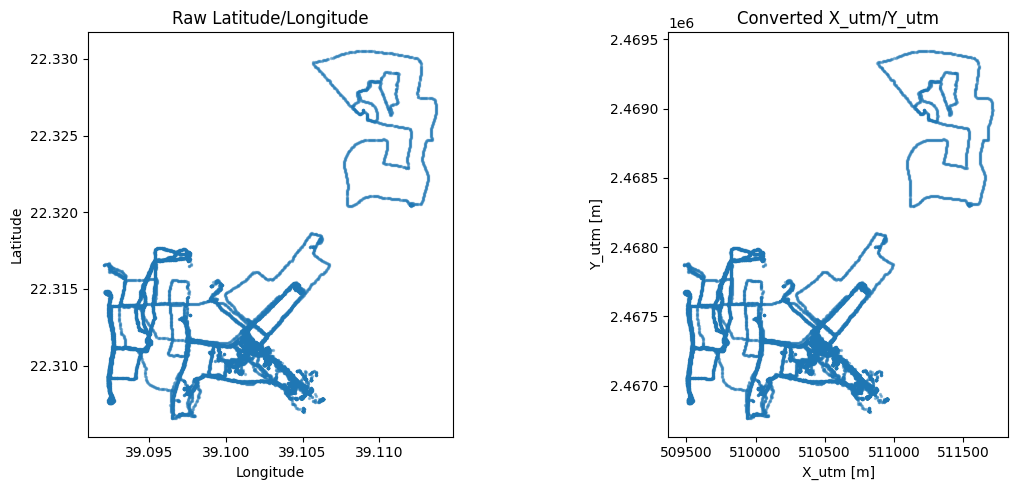

Step check on consecutive aligned samples:
  pair 0-1: raw_ll_m=0.426, utm_m=0.427
  pair 1-2: raw_ll_m=4.603, utm_m=4.585
  pair 2-3: raw_ll_m=7.333, utm_m=7.320
  pair 3-4: raw_ll_m=8.799, utm_m=8.782
selected feature families = RSRP + RSRQ
Aligned rows: 14,239
feature matrix shape = (14239, 156)
first 15 selected column names = ['RSRP1__CELL_101_1850', 'RSRP1__CELL_11_1850', 'RSRP1__CELL_126_1850', 'RSRP1__CELL_127_1850', 'RSRP1__CELL_128_1850', 'RSRP1__CELL_15_1850', 'RSRP1__CELL_15_6350', 'RSRP1__CELL_17_1850', 'RSRP1__CELL_181_1850', 'RSRP1__CELL_198_1850', 'RSRP1__CELL_198_6350', 'RSRP1__CELL_239_40590', 'RSRP1__CELL_243_40590', 'RSRP1__CELL_306_1850', 'RSRP1__CELL_307_1850']
observed ratio = 0.0277


In [ ]:
print("Aligning GPS to (file_id, TimeBin) with nearest sample per file...")

loc_ref = fp_df[fp_df['Latitude'].notna() & fp_df['Longitude'].notna()][['file_id', 'time_sec', 'Latitude', 'Longitude']].copy()
loc_ref = loc_ref.sort_values(['file_id', 'time_sec'])

aligned_parts = []
for fid, g in wide_df.groupby('file_id', sort=False):
    g = g.sort_values('time_sec_bin').copy()
    r = loc_ref[loc_ref['file_id'] == fid].copy()
    if len(r) == 0:
        continue
    m = pd.merge_asof(
        g,
        r[['time_sec', 'Latitude', 'Longitude']].sort_values('time_sec'),
        left_on='time_sec_bin',
        right_on='time_sec',
        direction='nearest'
    )
    m['file_id'] = fid
    aligned_parts.append(m)

if len(aligned_parts) == 0:
    raise RuntimeError('GPS alignment failed: no aligned rows.')

aligned = pd.concat(aligned_parts, ignore_index=True)
aligned = aligned[aligned['Latitude'].notna() & aligned['Longitude'].notna()].copy()

transformer = Transformer.from_crs("EPSG:4326", "EPSG:32637", always_xy=True)
x_utm, y_utm = transformer.transform(aligned['Longitude'].to_numpy(dtype=np.float64), aligned['Latitude'].to_numpy(dtype=np.float64))
aligned['X_utm'] = x_utm
aligned['Y_utm'] = y_utm

preview_cols = ['file_id', 'TimeBin', 'Latitude', 'Longitude', 'X_utm', 'Y_utm']
print(aligned[preview_cols].head(10).to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].scatter(aligned['Longitude'], aligned['Latitude'], s=2, alpha=0.4)
axes[0].set_title('Raw Latitude/Longitude')
axes[0].set_xlabel('Longitude')
axes[0].set_ylabel('Latitude')
axes[0].set_aspect('equal', adjustable='box')
axes[1].scatter(aligned['X_utm'], aligned['Y_utm'], s=2, alpha=0.4)
axes[1].set_title('Converted X_utm/Y_utm')
axes[1].set_xlabel('X_utm [m]')
axes[1].set_ylabel('Y_utm [m]')
axes[1].set_aspect('equal', adjustable='box')
plt.tight_layout()
plt.show()

step_rows = None
for fid, g in aligned.sort_values(['file_id', 'time_sec_bin']).groupby('file_id'):
    if len(g) >= 5:
        step_rows = g.head(5).copy()
        break
if step_rows is not None:
    lat = np.deg2rad(step_rows['Latitude'].to_numpy())
    lon = np.deg2rad(step_rows['Longitude'].to_numpy())
    dlat = np.diff(lat)
    dlon = np.diff(lon)
    a = np.sin(dlat/2.0)**2 + np.cos(lat[:-1]) * np.cos(lat[1:]) * np.sin(dlon/2.0)**2
    c = 2.0 * np.arctan2(np.sqrt(a), np.sqrt(1.0 - a))
    step_raw_m = 6371000.0 * c
    dx = np.diff(step_rows['X_utm'].to_numpy())
    dy = np.diff(step_rows['Y_utm'].to_numpy())
    step_utm_m = np.sqrt(dx*dx + dy*dy)
    print("Step check on consecutive aligned samples:")
    for i in range(len(step_raw_m)):
        print(f"  pair {i}-{i+1}: raw_ll_m={step_raw_m[i]:.3f}, utm_m={step_utm_m[i]:.3f}")

id_cols = {'file_id', 'TimeBin', 'time_sec_bin', 'time_sec', 'Latitude', 'Longitude', 'X_utm', 'Y_utm'}
all_feature_cols = [c for c in aligned.columns if c not in id_cols]
feature_cols = [
    c for c in all_feature_cols
    if c.startswith('RSRP1__') or c.startswith('RSRP2__') or c.startswith('RSRQ1__') or c.startswith('RSRQ2__')
]

X_val_df = aligned[feature_cols].copy()
X_val = X_val_df.to_numpy(dtype=np.float64)
X_mask = np.isfinite(X_val).astype(np.float64)
X_model = np.where(np.isfinite(X_val), X_val, 0.0)

features_val = X_val
features_mask = X_mask
features_model = X_model
positions_latlon = aligned[['Latitude', 'Longitude']].to_numpy(dtype=np.float64)
positions_utm = aligned[['X_utm', 'Y_utm']].to_numpy(dtype=np.float64)
timestamps = aligned['time_sec_bin'].to_numpy(dtype=np.float64)
file_ids = aligned['file_id'].to_numpy()
data = aligned.copy()
FEATURE_COLS = feature_cols

print("selected feature families = RSRP + RSRQ")
print(f"Aligned rows: {len(aligned):,}")
print(f"feature matrix shape = {X_val.shape}")
print(f"first 15 selected column names = {FEATURE_COLS[:15]}")
print(f"observed ratio = {X_mask.mean():.4f}")


## 3 — Alignment and Coordinate Conversion


In [ ]:
print(f"UTM positions shape: {positions_utm.shape}")
print(f"Easting  range: {positions_utm[:,0].min():.1f} – {positions_utm[:,0].max():.1f} m")
print(f"Northing range: {positions_utm[:,1].min():.1f} – {positions_utm[:,1].max():.1f} m")
print("Using X_utm/Y_utm for D_true; raw Latitude/Longitude retained for verification.")


UTM positions shape: (14239, 2)
Easting  range: 509481.3 – 511712.0 m
Northing range: 2466764.0 – 2469417.7 m
Using X_utm/Y_utm for D_true; raw Latitude/Longitude retained for verification.


## 4 — Subsampling Within Files


In [ ]:
def subsample_within_files(file_ids_arr, n_target):
    n_all = len(file_ids_arr)
    if n_all <= n_target:
        return np.arange(n_all)
    ids = np.asarray(file_ids_arr)
    uniq = np.unique(ids)
    idx_parts = []
    for fid in uniq:
        idx = np.where(ids == fid)[0]
        n_f = len(idx)
        k = max(1, int(round(n_target * (n_f / n_all))))
        k = min(k, n_f)
        choose = np.linspace(0, n_f - 1, k, dtype=int)
        idx_parts.append(idx[choose])
    idx_sub = np.sort(np.concatenate(idx_parts))
    if len(idx_sub) > n_target:
        choose = np.linspace(0, len(idx_sub) - 1, n_target, dtype=int)
        idx_sub = idx_sub[choose]
    return idx_sub

N_total = len(features_val)
idx_sub = subsample_within_files(file_ids, SUBSAMPLE_N)

feat_sub = features_val[idx_sub]
feat_model_sub = features_model[idx_sub]
mask_sub = features_mask[idx_sub]
pos_sub = positions_utm[idx_sub]
latlon_sub = positions_latlon[idx_sub]
time_sub = timestamps[idx_sub]
file_sub = file_ids[idx_sub]
N = len(idx_sub)

print(f"Subsampled within files: {N_total:,} → {N}")
print(f"Feature matrix (val/mask/model): {feat_sub.shape} / {mask_sub.shape} / {feat_model_sub.shape}")
print(f"Feature matrix shape: {features_val.shape}")
print(f"First 15 selected column names: {FEATURE_COLS[:15]}")
if features_val.shape[1] <= 36:
    print("WARNING: feature dimension still small; sparse redesign may have failed.")


Subsampled within files: 14,239 → 3999
Feature matrix (val/mask/model): (3999, 156) / (3999, 156) / (3999, 156)
Feature matrix shape: (14239, 156)
First 15 selected column names: ['RSRP1__CELL_101_1850', 'RSRP1__CELL_11_1850', 'RSRP1__CELL_126_1850', 'RSRP1__CELL_127_1850', 'RSRP1__CELL_128_1850', 'RSRP1__CELL_15_1850', 'RSRP1__CELL_15_6350', 'RSRP1__CELL_17_1850', 'RSRP1__CELL_181_1850', 'RSRP1__CELL_198_1850', 'RSRP1__CELL_198_6350', 'RSRP1__CELL_239_40590', 'RSRP1__CELL_243_40590', 'RSRP1__CELL_306_1850', 'RSRP1__CELL_307_1850']


## 5 — Signal Dissimilarity Matrix


In [ ]:
print("Computing overlap-aware signal dissimilarity...")

def overlap_cosine_distance(X_val, X_mask, overlap_lambda=0.3, min_overlap=5, chunk=256):
    X = np.where(np.isfinite(X_val), X_val, 0.0)
    M = (X_mask > 0)
    N_local = X.shape[0]
    obs_count = M.sum(axis=1).astype(np.float64)
    D = np.full((N_local, N_local), np.nan, dtype=np.float64)
    np.fill_diagonal(D, 0.0)

    for start in range(0, N_local, chunk):
        end = min(start + chunk, N_local)
        B = end - start
        common = M[start:end, None, :] & M[None, :, :]
        cnt = common.sum(axis=2).astype(np.float64)
        valid = cnt >= min_overlap
        c = common.astype(np.float64)

        x_block = X[start:end]
        cnt_safe = np.maximum(cnt, 1.0)
        mu_i = (c * x_block[:, None, :]).sum(axis=2) / cnt_safe
        mu_j = (c * X[None, :, :]).sum(axis=2) / cnt_safe

        xc = c * (x_block[:, None, :] - mu_i[:, :, None])
        yc = c * (X[None, :, :] - mu_j[:, :, None])

        dot = (xc * yc).sum(axis=2)
        nx = np.sqrt((xc * xc).sum(axis=2))
        ny = np.sqrt((yc * yc).sum(axis=2))
        denom = np.maximum(nx * ny, 1e-12)
        cos = np.clip(dot / denom, -1.0, 1.0)

        overlap_ratio = cnt / np.maximum(np.maximum(obs_count[start:end, None], obs_count[None, :]), 1.0)
        dist = 1.0 - cos + overlap_lambda * (1.0 - overlap_ratio)
        dist = np.clip(dist, 0.0, None)
        dist[~valid] = np.nan

        for k in range(B):
            dist[k, start + k] = 0.0

        D[start:end] = dist

    D = 0.5 * (D + D.T)
    np.fill_diagonal(D, 0.0)
    return D

tri = np.triu_indices(N, k=1)
D_true = cdist(pos_sub, pos_sub, metric='euclidean')
D_true_flat = D_true[tri]

print("selected feature families = RSRP + RSRQ")
print(f"feature matrix shape = {feat_sub.shape}")
print(f"first 15 selected column names = {FEATURE_COLS[:15]}")
print(f"observed ratio = {mask_sub.mean():.6f}")

sweep_rows = []
best_pick = None
for mo in [2, 3, 5]:
    for ol in [0.1, 0.3]:
        D_try = overlap_cosine_distance(feat_sub, mask_sub, overlap_lambda=ol, min_overlap=mo)
        d_try = D_try[tri]
        finite_try = np.isfinite(d_try)
        finite_frac_try = float(finite_try.mean()) if len(finite_try) else 0.0
        fin_try = finite_try & np.isfinite(D_true_flat)
        if fin_try.sum() > 10:
            rho_try, _ = spearmanr(d_try[fin_try], D_true_flat[fin_try])
            pear_try = float(np.corrcoef(d_try[fin_try], D_true_flat[fin_try])[0, 1])
        else:
            rho_try, pear_try = np.nan, np.nan
        sweep_rows.append({
            'min_overlap': mo,
            'overlap_lambda': ol,
            'finite_offdiag_fraction': finite_frac_try,
            'spearman_signal_gps': float(rho_try) if np.isfinite(rho_try) else np.nan,
            'pearson_signal_gps': pear_try,
            'D_signal': D_try
        })

        cand = (rho_try if np.isfinite(rho_try) else -np.inf, finite_frac_try)
        if best_pick is None or cand > best_pick[0]:
            best_pick = (cand, sweep_rows[-1])

sweep_df = pd.DataFrame([
    {
        'min_overlap': r['min_overlap'],
        'overlap_lambda': r['overlap_lambda'],
        'finite_offdiag_fraction': r['finite_offdiag_fraction'],
        'spearman_signal_gps': r['spearman_signal_gps'],
        'pearson_signal_gps': r['pearson_signal_gps']
    }
    for r in sweep_rows
]).sort_values(
    by=['spearman_signal_gps', 'finite_offdiag_fraction'],
    ascending=[False, False],
    na_position='last'
).reset_index(drop=True)

print("Overlap sweep (signal-only)")
print(sweep_df.to_string(index=False))

MIN_OVERLAP = int(best_pick[1]['min_overlap'])
OVERLAP_LAMBDA = float(best_pick[1]['overlap_lambda'])
D_signal = best_pick[1]['D_signal']

d_sig = D_signal[tri]
finite_sig = np.isfinite(d_sig)
fin = finite_sig & np.isfinite(D_true_flat)
if fin.sum() > 10:
    rho_sig, _ = spearmanr(d_sig[fin], D_true_flat[fin])
    pear_sig = float(np.corrcoef(d_sig[fin], D_true_flat[fin])[0, 1])
else:
    rho_sig, pear_sig = np.nan, np.nan

finite_offdiag_frac = float(finite_sig.mean()) if len(finite_sig) else 0.0
if finite_sig.any():
    d_min = np.nanmin(d_sig[finite_sig])
    d_med = np.nanmedian(d_sig[finite_sig])
    d_max = np.nanmax(d_sig[finite_sig])
    d_std = np.nanstd(d_sig[finite_sig])
else:
    d_min, d_med, d_max, d_std = np.nan, np.nan, np.nan, np.nan

print(f"chosen MIN_OVERLAP = {MIN_OVERLAP}")
print(f"chosen OVERLAP_LAMBDA = {OVERLAP_LAMBDA:.3f}")
print(f"D_signal finite_offdiag fraction: {finite_offdiag_frac:.6f}")
print(f"D_signal min/median/max/std: {d_min:.6f} / {d_med:.6f} / {d_max:.6f} / {d_std:.6f}")
print(f"D_signal range: [{np.nanmin(D_signal):.6f}, {np.nanmax(D_signal):.6f}]")
print(f"Spearman(D_signal, D_true): {rho_sig:.6f}")
print(f"Pearson(D_signal, D_true): {pear_sig:.6f}")


Computing overlap-aware signal dissimilarity...
selected feature families = RSRP + RSRQ
feature matrix shape = (3999, 156)
first 15 selected column names = ['RSRP1__CELL_101_1850', 'RSRP1__CELL_11_1850', 'RSRP1__CELL_126_1850', 'RSRP1__CELL_127_1850', 'RSRP1__CELL_128_1850', 'RSRP1__CELL_15_1850', 'RSRP1__CELL_15_6350', 'RSRP1__CELL_17_1850', 'RSRP1__CELL_181_1850', 'RSRP1__CELL_198_1850', 'RSRP1__CELL_198_6350', 'RSRP1__CELL_239_40590', 'RSRP1__CELL_243_40590', 'RSRP1__CELL_306_1850', 'RSRP1__CELL_307_1850']
observed ratio = 0.027696
Overlap sweep (signal-only)
 min_overlap  overlap_lambda  finite_offdiag_fraction  spearman_signal_gps  pearson_signal_gps
           2             0.3                 0.097501             0.175936            0.210285
           2             0.1                 0.097501             0.175929            0.199112
           3             0.3                 0.097498             0.175899            0.212087
           3             0.1                 0.0974

## 5b — Temporal Distance Matrix (D_time)

In [ ]:
# ── Compute D_time (temporal distance matrix) ────────────────────────────────
# Points close in time are likely close in space (walking user).
# Cross-file differences are meaningless — set to NaN.

print("Computing D_time...")
dt_raw     = np.abs(time_sub[:, None] - time_sub[None, :])
file_match = (file_sub[:, None] == file_sub[None, :])
D_time_raw = np.where(file_match, dt_raw, np.nan)
np.fill_diagonal(D_time_raw, 0.0)

tri = np.triu_indices(N, k=1)
d_time_flat = D_time_raw[tri]
fin_time = np.isfinite(d_time_flat) & np.isfinite(D_true_flat)
rho_time  = spearmanr(d_time_flat[fin_time], D_true_flat[fin_time])[0] if fin_time.sum() > 10 else np.nan

print(f"D_time finite fraction (same-file pairs): {np.isfinite(d_time_flat).mean():.4f}")
print(f"Spearman(D_time, D_true): {rho_time:.6f}")
print(f"D_time range: [{np.nanmin(D_time_raw):.2f}, {np.nanmax(D_time_raw):.2f}] seconds")


Computing D_time...
D_time finite fraction (same-file pairs): 0.0320
Spearman(D_time, D_true): 0.529730
D_time range: [0.00, 4820.00] seconds


## 5c — Normalize Distance Matrices

In [ ]:
# ── Normalize distance matrices to [0, 1] ────────────────────────────────────
# Use 99th percentile of finite values to avoid outlier inflation.

def normalize_distance_matrix(D, label=""):
    t = np.triu_indices(D.shape[0], k=1)
    fv = D[t][np.isfinite(D[t])]
    if len(fv) == 0:
        print(f"  WARNING: {label} has no finite values")
        return D.copy()
    p99 = max(np.percentile(fv, 99), 1e-9)
    Dn  = np.clip(D / p99, 0.0, 1.0)
    Dn  = np.where(np.isfinite(D), Dn, np.nan)
    np.fill_diagonal(Dn, 0.0)
    print(f"  {label}: p99={p99:.4f}, finite={np.isfinite(Dn[t]).mean():.4f}, "
          f"range=[{np.nanmin(Dn):.4f}, {np.nanmax(Dn):.4f}]")
    return Dn

print("Normalizing distance matrices...")
D_signal_norm = normalize_distance_matrix(D_signal,   "D_signal")
D_time_norm   = normalize_distance_matrix(D_time_raw, "D_time")

def quick_spearman(D_norm, D_true_mat, label=""):
    t   = np.triu_indices(D_norm.shape[0], k=1)
    fin = np.isfinite(D_norm[t]) & np.isfinite(D_true_mat[t])
    if fin.sum() < 10:
        print(f"  {label}: insufficient finite pairs")
        return np.nan
    rho, _ = spearmanr(D_norm[t][fin], D_true_mat[t][fin])
    print(f"  {label}: Spearman={rho:.6f}  (finite pairs={fin.sum():,})")
    return rho

print("\nCorrelation with GPS truth:")
rho_sig_norm  = quick_spearman(D_signal_norm, D_true, "D_signal_norm")
rho_time_norm = quick_spearman(D_time_norm,   D_true, "D_time_norm")


Normalizing distance matrices...
  D_signal: p99=0.2004, finite=0.0975, range=[0.0000, 1.0000]
  D_time: p99=3930.0000, finite=0.0320, range=[0.0000, 1.0000]

Correlation with GPS truth:
  D_signal_norm: Spearman=0.175927  (finite pairs=779,421)
  D_time_norm: Spearman=0.529765  (finite pairs=255,414)


## 6 — Training Distance Selection (Signal Only)


## 6 — Weighted Fusion: Learn Distance Weights

Pair coverage:
  Both finite : 85,451  (1.1%)
  Signal only : 693,970  (8.7%)
  Time only   : 169,963  (2.1%)

Train points: 3199 | Test points: 800
Train eval pairs: 55,690 | Test eval pairs: 3,206

  Weighted Fusion Results  (both-finite pairs only)
  Best alpha (w_signal) : 0.30
  1-alpha    (w_time)   : 0.70

  Method                   Train Spearman  Test Spearman
  ------------------------------------------------------
  D_signal only                  0.239276       0.242951
  D_time only                    0.452852       0.484920
  D_fused (best)                 0.455916       0.478527

D_fused_full coverage: 11.9% of pairs


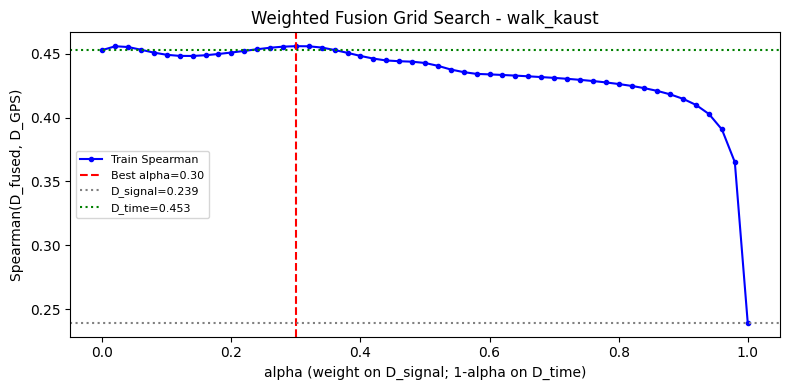

TRAIN_DISTANCE_SOURCE = fused_alpha=0.3
D_train is now D_fused_full. Siamese training will use this.


In [ ]:
# ── Weighted Fusion: GPS-supervised grid search over alpha ────────────────────
#
# Formula: D_fused = alpha * D_signal_norm + (1-alpha) * D_time_norm
#
# Grid search finds the alpha that maximises Spearman(D_fused, D_GPS)
# evaluated ONLY on pairs where BOTH matrices are finite.
# This prevents coverage effects from gaming the search.
#
# GPS is used ONLY here to pick alpha.
# The Siamese network never sees GPS labels.

from scipy.stats import spearmanr as _sp

tri = np.triu_indices(N, k=1)
D_true_flat = D_true[tri]

# Coverage breakdown
both_finite  = np.isfinite(D_signal_norm[tri]) & np.isfinite(D_time_norm[tri])
only_sig_fin = np.isfinite(D_signal_norm[tri]) & ~np.isfinite(D_time_norm[tri])
only_tim_fin = ~np.isfinite(D_signal_norm[tri]) & np.isfinite(D_time_norm[tri])
print("Pair coverage:")
print(f"  Both finite : {both_finite.sum():,}  ({both_finite.mean()*100:.1f}%)")
print(f"  Signal only : {only_sig_fin.sum():,}  ({only_sig_fin.mean()*100:.1f}%)")
print(f"  Time only   : {only_tim_fin.sum():,}  ({only_tim_fin.mean()*100:.1f}%)")

# Train / test split on points
np.random.seed(42)
perm      = np.random.permutation(N)
train_idx = np.sort(perm[:int(0.8 * N)])
test_idx  = np.sort(perm[int(0.8 * N):])
train_set = set(train_idx.tolist())
test_set  = set(test_idx.tolist())
ii, jj    = tri
train_pairs = np.array([i in train_set and j in train_set for i, j in zip(ii, jj)])
test_pairs  = np.array([i in test_set  and j in test_set  for i, j in zip(ii, jj)])
train_eval  = train_pairs & both_finite & np.isfinite(D_true_flat)
test_eval   = test_pairs  & both_finite & np.isfinite(D_true_flat)
print(f"\nTrain points: {len(train_idx)} | Test points: {len(test_idx)}")
print(f"Train eval pairs: {train_eval.sum():,} | Test eval pairs: {test_eval.sum():,}")

if train_eval.sum() < 10:
    print("WARNING: too few both-finite train pairs. Using D_signal as fallback.")
    D_train   = D_signal.copy()
    best_name = "signal_fallback"
    FUSION_ALPHA = 1.0
else:
    # Grid search
    dsf  = D_signal_norm[tri]
    dtf  = D_time_norm[tri]
    res  = []
    for alpha in np.linspace(0.0, 1.0, 51):
        df2  = alpha * dsf + (1 - alpha) * dtf
        rh   = _sp(df2[train_eval], D_true_flat[train_eval])[0]
        res.append({"alpha": float(alpha),
                    "rho_train": float(rh) if np.isfinite(rh) else np.nan})

    rdf        = pd.DataFrame(res)
    br         = rdf.dropna(subset=["rho_train"]).sort_values("rho_train", ascending=False).iloc[0]
    best_alpha = float(br["alpha"])
    best_rho_train = float(br["rho_train"])

    # Test split evaluation
    dfb  = best_alpha * dsf + (1 - best_alpha) * dtf
    rte  = _sp(dfb[test_eval], D_true_flat[test_eval])[0] if test_eval.sum() > 10 else np.nan

    def spr(d, m):
        fin2 = m & both_finite & np.isfinite(D_true_flat)
        return _sp(d[fin2], D_true_flat[fin2])[0] if fin2.sum() > 10 else np.nan

    sep  = "=" * 62
    dash = "-" * 54
    print("\n" + sep)
    print("  Weighted Fusion Results  (both-finite pairs only)")
    print(sep)
    print(f"  Best alpha (w_signal) : {best_alpha:.2f}")
    print(f"  1-alpha    (w_time)   : {1-best_alpha:.2f}")
    print()
    print("  " + "Method".ljust(24) + "Train Spearman".rjust(15) + "Test Spearman".rjust(15))
    print("  " + dash)
    print("  " + "D_signal only".ljust(24) + f"{spr(dsf, train_pairs):15.6f}" + f"{spr(dsf, test_pairs):15.6f}")
    print("  " + "D_time only".ljust(24)   + f"{spr(dtf, train_pairs):15.6f}" + f"{spr(dtf, test_pairs):15.6f}")
    print("  " + "D_fused (best)".ljust(24)+ f"{best_rho_train:15.6f}" + f"{float(rte):15.6f}")
    print(sep)

    # Build full D_fused matrix with NaN-safe fallback for Siamese coverage
    fsm  = np.isfinite(D_signal_norm)
    ftm  = np.isfinite(D_time_norm)
    Dff  = np.full((N, N), np.nan)
    bm   = fsm & ftm
    osm  = fsm & ~ftm
    otm  = ~fsm & ftm
    Dff[bm]  = best_alpha * D_signal_norm[bm] + (1 - best_alpha) * D_time_norm[bm]
    Dff[osm] = D_signal_norm[osm]
    Dff[otm] = D_time_norm[otm]
    np.fill_diagonal(Dff, 0.0)
    print(f"\nD_fused_full coverage: {np.isfinite(Dff[tri]).mean()*100:.1f}% of pairs")

    # Plot sweep
    plt.figure(figsize=(8, 4))
    plt.plot(rdf["alpha"], rdf["rho_train"], "b-o", ms=3, label="Train Spearman")
    plt.axvline(best_alpha, color="r", linestyle="--", label=f"Best alpha={best_alpha:.2f}")
    plt.axhline(spr(dsf, train_pairs), color="gray",  linestyle=":", label=f"D_signal={spr(dsf,train_pairs):.3f}")
    plt.axhline(spr(dtf, train_pairs), color="green", linestyle=":", label=f"D_time={spr(dtf,train_pairs):.3f}")
    plt.xlabel("alpha (weight on D_signal; 1-alpha on D_time)")
    plt.ylabel("Spearman(D_fused, D_GPS)")
    plt.title("Weighted Fusion Grid Search - walk_kaust")
    plt.legend(fontsize=8)
    plt.tight_layout()
    plt.show()

    D_train      = Dff.copy()
    best_name    = "fused_alpha=" + str(round(best_alpha, 2))
    FUSION_ALPHA = best_alpha

print("TRAIN_DISTANCE_SOURCE = " + best_name)
print("D_train is now D_fused_full. Siamese training will use this.")


## 7 — Signal Distance Diagnostics


In [ ]:
tri = np.triu_indices(N, k=1)
D_true_flat = D_true[tri]
d_train_flat = D_train[tri]
fin = np.isfinite(d_train_flat) & np.isfinite(D_true_flat)
if fin.sum() > 10:
    rho, _ = spearmanr(d_train_flat[fin], D_true_flat[fin])
    pear = np.corrcoef(d_train_flat[fin], D_true_flat[fin])[0, 1]
else:
    rho, pear = np.nan, np.nan
print(f"Signal-only training distance Spearman={rho:.6f}, Pearson={pear:.6f}")


Signal-only training distance Spearman=0.285190, Pearson=0.284819


## 8 — Geodesic Disabled


In [ ]:
print("Time fusion: OFF")
print("Geodesic: OFF")


Time fusion: OFF
Geodesic: OFF


## 9 — Classical Baseline: MDS


Running MDS on selected distance matrix: fused_alpha=0.3...
  MDS stress: 913926.54
  Computed in 719.1s


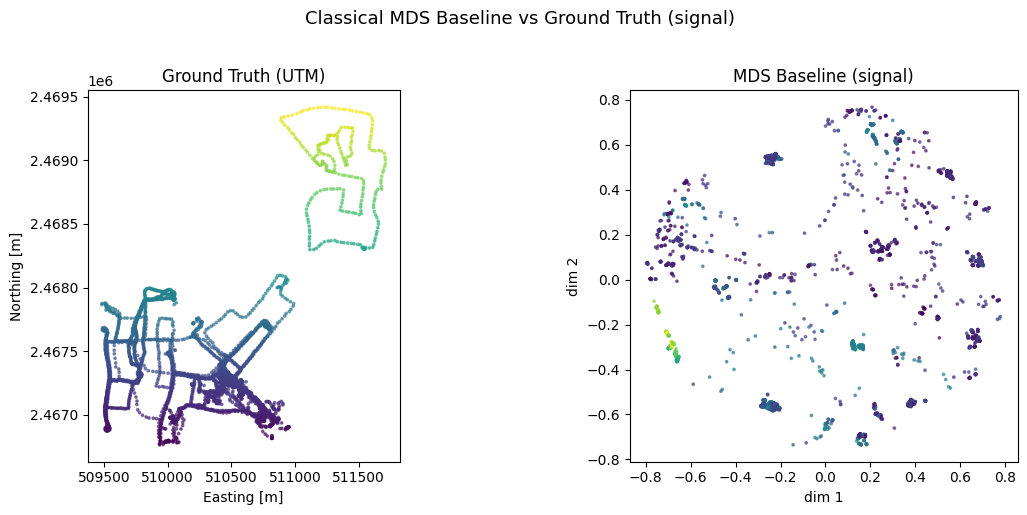

In [ ]:
print(f"Running MDS on selected distance matrix: {best_name}...")
t0 = _time.time()

D_mds_input = D_train.copy()
D_mds_input = 0.5 * (D_mds_input + D_mds_input.T)
np.fill_diagonal(D_mds_input, 0.0)
fin_mds = np.isfinite(D_mds_input)
if not fin_mds.all():
    if fin_mds.any():
        fill_val = np.nanmax(D_mds_input[fin_mds])
        D_mds_input[~fin_mds] = fill_val
    else:
        raise RuntimeError('D_train has no finite values for MDS.')

mds = MDS(n_components=MDS_COMPONENTS, dissimilarity='precomputed', random_state=42, n_init=4, max_iter=500, normalized_stress='auto')
proj_mds = mds.fit_transform(D_mds_input)

print(f"  MDS stress: {mds.stress_:.2f}")
print(f"  Computed in {_time.time()-t0:.1f}s")

def plot_colorized(coords, ref_coords, title="", ax=None, show=True):
    if ax is None:
        fig, ax = plt.subplots(figsize=(5, 5))
    c = ref_coords[:, 1]
    sc = ax.scatter(coords[:, 0], coords[:, 1], c=c, cmap='viridis', s=3, alpha=0.6)
    ax.set_title(title)
    ax.set_aspect('equal')
    if show:
        plt.colorbar(sc)
        plt.tight_layout()
        plt.show()
    return sc

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
plot_colorized(pos_sub, pos_sub, title="Ground Truth (UTM)", ax=axes[0], show=False)
axes[0].set_xlabel("Easting [m]")
axes[0].set_ylabel("Northing [m]")
plot_colorized(proj_mds, pos_sub, title="MDS Baseline (signal)", ax=axes[1], show=False)
axes[1].set_xlabel("dim 1")
axes[1].set_ylabel("dim 2")
plt.suptitle("Classical MDS Baseline vs Ground Truth (signal)", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


## 10 — Siamese Neural Network: Forward Charting Function

**What changed:** The input dimension of the Siamese network adapts to our 42-dimensional walk_kaust feature vector (vs the old pipeline's per-cell-RSSI width). The network architecture is otherwise **identical**: shared-weight encoder mapping features → 2D channel chart coordinates, trained with a contrastive loss on the fused dissimilarity matrix.

**What stayed the same:**
- Siamese architecture with shared weights
- Contrastive loss: $\mathcal{L} = \sum_{i,j} (\| z_i - z_j \| - D_{\text{fused}}(i,j))^2$
- 5-layer encoder: `D → 256 → 128 → 64 → 32 → 2`
- Batch sampling of random pairs


In [ ]:
class Encoder(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        h1 = max(64, input_dim * 8)
        h2 = max(32, h1 // 2)
        h3 = max(16, h2 // 2)
        self.net = nn.Sequential(
            nn.Linear(input_dim, h1), nn.ReLU(), nn.Dropout(0.1), nn.BatchNorm1d(h1),
            nn.Linear(h1, h2),        nn.ReLU(), nn.BatchNorm1d(h2),
            nn.Linear(h2, h3),        nn.ReLU(), nn.BatchNorm1d(h3),
            nn.Linear(h3, 2),
        )
        self._arch = f"{input_dim} -> {h1} -> {h2} -> {h3} -> 2"
    def forward(self, x):
        return self.net(x)

class PairDataset(Dataset):
    def __init__(self, features, D_train, n_pairs_per_epoch=50000):
        self.features = torch.tensor(features, dtype=torch.float32)
        self.D_train = D_train
        self.N = features.shape[0]
        self.n_pairs = n_pairs_per_epoch
        fin = np.isfinite(D_train)
        np.fill_diagonal(fin, False)
        self.valid_i, self.valid_j = np.where(fin)

    def __len__(self):
        return self.n_pairs

    def __getitem__(self, _):
        idx = np.random.randint(len(self.valid_i))
        i, j = self.valid_i[idx], self.valid_j[idx]
        return (self.features[i], self.features[j], torch.tensor(self.D_train[i, j], dtype=torch.float32))

feat_model = feat_model_sub.copy()
INPUT_DIM = feat_model.shape[1]
_tmp_enc = Encoder(INPUT_DIM)
print(f"Encoder input dim: {INPUT_DIM}")
print(f"Architecture: {_tmp_enc._arch}")
del _tmp_enc


Encoder input dim: 156
Architecture: 156 -> 1248 -> 624 -> 312 -> 2


In [ ]:
# ── Siamese training setup ───────────────────────────────────────────────────
# Diagnostic: confirm D_train is the fused matrix, not D_signal
print("--- D_train verification ---")
off      = ~np.eye(N, dtype=bool)
fin_mask = np.isfinite(D_train) & off
fin_frac = fin_mask.sum() / off.sum()
print(f"  D_train finite fraction : {fin_frac:.4f}")
print(f"  D_train finite pairs    : {fin_mask.sum():,}")
print(f"  D_train value range     : [{np.nanmin(D_train[off]):.4f}, {np.nanmax(D_train[off]):.4f}]")
print(f"  TRAIN_DISTANCE_SOURCE   : {best_name}")

if fin_mask.sum() == 0:
    raise RuntimeError("D_train has no finite values. Check fusion cell.")

d_max = np.nanpercentile(D_train[fin_mask], 99)
if not np.isfinite(d_max) or d_max <= 0:
    d_max = np.nanmax(D_train[fin_mask])
if not np.isfinite(d_max) or d_max <= 0:
    d_max = 1.0
print(f"  d_max (99th pct)        : {d_max:.6f}")

D_train_normed = np.clip(D_train / max(d_max, 1e-9), 0.0, 1.0)
D_train_normed = np.where(np.isfinite(D_train_normed), D_train_normed, 1.0)
np.fill_diagonal(D_train_normed, 0.0)
print(f"  D_train_normed range    : [{D_train_normed[off].min():.4f}, {D_train_normed[off].max():.4f}]")
print("----------------------------")

mu_train = np.nanmean(feat_model, axis=0)
sd_train = np.nanstd(feat_model, axis=0)
sd_train = np.where(sd_train > 1e-9, sd_train, 1.0)
feat_train = (feat_model - mu_train) / sd_train

encoder   = Encoder(INPUT_DIM).to(DEVICE)
optimizer = optim.Adam(encoder.parameters(), lr=SIAMESE_LR)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=SIAMESE_EPOCHS)

dataset = PairDataset(feat_train, D_train_normed, n_pairs_per_epoch=60000)
loader  = DataLoader(dataset, batch_size=SIAMESE_BATCH, shuffle=True,
                     num_workers=0, drop_last=True)

print(f"Training Siamese network: {SIAMESE_EPOCHS} epochs, batch={SIAMESE_BATCH}, "
      f"lr={SIAMESE_LR}, device={DEVICE}")
print("-" * 60)

loss_history = []
for epoch in range(1, SIAMESE_EPOCHS + 1):
    encoder.train()
    epoch_loss = 0.0
    n_batches  = 0
    for feat_i, feat_j, d_target in loader:
        feat_i = feat_i.to(DEVICE); feat_j = feat_j.to(DEVICE)
        d_target = d_target.to(DEVICE)
        z_i = encoder(feat_i); z_j = encoder(feat_j)
        loss = ((torch.norm(z_i - z_j, dim=1) - d_target) ** 2).mean()
        optimizer.zero_grad(); loss.backward()
        torch.nn.utils.clip_grad_norm_(encoder.parameters(), max_norm=1.0)
        optimizer.step()
        epoch_loss += loss.item(); n_batches += 1
    scheduler.step()
    avg_loss = epoch_loss / max(n_batches, 1)
    loss_history.append(avg_loss)
    if epoch % 20 == 0 or epoch == 1:
        print(f"  Epoch {epoch:3d}/{SIAMESE_EPOCHS}  loss={avg_loss:.6f}  "
              f"lr={scheduler.get_last_lr()[0]:.2e}")

print("Training complete!")


--- D_train verification ---
  D_train finite fraction : 0.1188
  D_train finite pairs    : 1,898,768
  D_train value range     : [0.0000, 1.0000]
  TRAIN_DISTANCE_SOURCE   : fused_alpha=0.3
  d_max (99th pct)        : 0.999447
  D_train_normed range    : [0.0000, 1.0000]
----------------------------
Training Siamese network: 200 epochs, batch=512, lr=0.001, device=cuda
------------------------------------------------------------
  Epoch   1/200  loss=0.256193  lr=1.00e-03
  Epoch  20/200  loss=0.121537  lr=9.76e-04
  Epoch  40/200  loss=0.118321  lr=9.05e-04
  Epoch  60/200  loss=0.116103  lr=7.94e-04
  Epoch  80/200  loss=0.117054  lr=6.55e-04
  Epoch 100/200  loss=0.115962  lr=5.00e-04
  Epoch 120/200  loss=0.116204  lr=3.45e-04
  Epoch 140/200  loss=0.114617  lr=2.06e-04
  Epoch 160/200  loss=0.114818  lr=9.55e-05
  Epoch 180/200  loss=0.115627  lr=2.45e-05
  Epoch 200/200  loss=0.114796  lr=0.00e+00
Training complete!


Channel chart positions: (3999, 2)


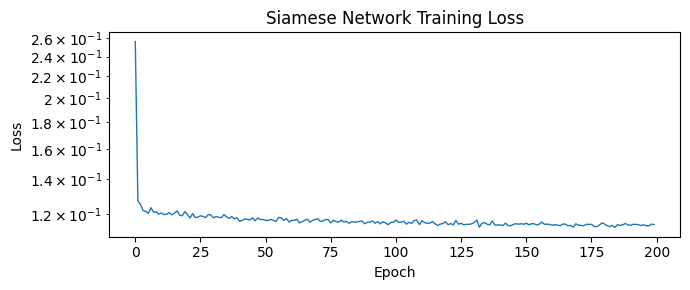

In [ ]:
# ── 10c. Extract channel chart positions ──────────────────────────
encoder.eval()
with torch.no_grad():
    feat_tensor = torch.tensor(feat_train, dtype=torch.float32).to(DEVICE)
    cc_positions = encoder(feat_tensor).cpu().numpy()

print(f"Channel chart positions: {cc_positions.shape}")
CAN_PLOT_CC = True
if not np.isfinite(cc_positions).all():
    print('WARNING: non-finite cc_positions; stop plotting')
    CAN_PLOT_CC = False
if np.std(cc_positions, axis=0).max() < 1e-3:
    print('WARNING: collapsed embedding')
    CAN_PLOT_CC = False

# Plot training loss
fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(loss_history, lw=1)
ax.set_xlabel("Epoch"); ax.set_ylabel("Loss")
ax.set_title("Siamese Network Training Loss")
ax.set_yscale('log')
plt.tight_layout(); plt.show()

## 11 — Evaluation & Visualization

**Unchanged from old pipeline.** We compute the standard channel charting quality metrics:

| Metric | Description |
|--------|-------------|
| **Kruskal Stress** | $\sqrt{\sum (d_{cc} - d_{train})^2 / \sum d_{train}^2}$ — lower is better |
| **Trustworthiness (TW)** | Do nearby CC neighbors correspond to nearby real neighbors? |
| **Continuity (CO)** | Do nearby real neighbors stay nearby in the CC? |
| **Spearman ρ** | Rank correlation between training and CC distances |
| **Shepard Diagram** | Scatter of training vs CC distances |


In [ ]:
# ── 11a. Metrics ──────────────────────────────────────────────────
from sklearn.manifold import trustworthiness as sklearn_tw

def continuity(D_high, X_low, n_neighbors=5):
    """Continuity metric (counterpart of trustworthiness)."""
    N = D_high.shape[0]
    D_low = cdist(X_low, X_low)

    nn_high = np.argsort(D_high, axis=1)[:, 1:n_neighbors+1]
    nn_low  = np.argsort(D_low,  axis=1)[:, 1:n_neighbors+1]

    M = 0
    for i in range(N):
        high_set = set(nn_high[i])
        low_set  = set(nn_low[i])
        missing = high_set - low_set
        for j in missing:
            rank_low = np.where(np.argsort(D_low[i]) == j)[0][0]
            M += max(0, rank_low - n_neighbors)

    denom = N * n_neighbors * (2 * N - 3 * n_neighbors - 1)
    if denom == 0:
        return 1.0
    return 1 - (2.0 / denom) * M

if not CAN_PLOT_CC:
    print('WARNING: invalid/collapsed embedding; skip CC metrics and plotting')
    D_cc = np.full((N, N), np.nan)
    d_train_flat = D_train[np.triu_indices(N, k=1)]
    d_cc_flat = np.full_like(d_train_flat, np.nan)
    d_cc_scaled = d_cc_flat.copy()
    kruskal_stress_raw = np.nan
    kruskal_stress_affine = np.nan
    kruskal_stress = np.nan
    rho_cc = np.nan
else:
    D_cc = cdist(cc_positions, cc_positions, metric='euclidean')
    d_train_flat = D_train[np.triu_indices(N, k=1)]
    d_cc_flat = D_cc[np.triu_indices(N, k=1)]
    fin_raw = np.isfinite(d_cc_flat) & np.isfinite(d_train_flat)
    if fin_raw.sum() < 10000:
        print('WARNING: too few finite pairs for reliable stress')
        kruskal_stress_raw = np.nan
    else:
        kruskal_stress_raw = np.sqrt(
            np.sum((d_cc_flat[fin_raw] - d_train_flat[fin_raw]) ** 2) /
            np.maximum(np.sum(d_train_flat[fin_raw] ** 2), 1e-12)
        )

    fin_shep = np.isfinite(d_cc_flat) & np.isfinite(d_train_flat)
    if fin_shep.sum() < 10:
        a_fit, b_fit = 1.0, 0.0
        d_cc_scaled = d_cc_flat.copy()
    else:
        x_fit = d_cc_flat[fin_shep]
        y_fit = d_train_flat[fin_shep]
        A = np.vstack([x_fit, np.ones(len(x_fit))]).T
        try:
            result = np.linalg.lstsq(A, y_fit, rcond=None)
            a_fit, b_fit = result[0]
        except np.linalg.LinAlgError:
            sx = np.nanstd(x_fit)
            sy = np.nanstd(y_fit)
            if sx > 1e-12:
                a_fit = sy / sx
                b_fit = np.nanmean(y_fit) - a_fit * np.nanmean(x_fit)
            else:
                a_fit, b_fit = 1.0, 0.0
        d_cc_scaled = a_fit * d_cc_flat + b_fit
        d_cc_scaled = np.where(np.isfinite(d_cc_scaled), d_cc_scaled, np.nanmedian(y_fit))

    fin_aff = np.isfinite(d_cc_scaled) & np.isfinite(d_train_flat)
    if fin_aff.sum() < 10000:
        print('WARNING: too few finite pairs for affine stress')
        kruskal_stress_affine = np.nan
    else:
        kruskal_stress_affine = np.sqrt(
            np.sum((d_cc_scaled[fin_aff] - d_train_flat[fin_aff]) ** 2) /
            np.maximum(np.sum(d_train_flat[fin_aff] ** 2), 1e-12)
        )

    kruskal_stress = kruskal_stress_affine
    if fin_aff.sum() > 0:
        rho_cc, _ = spearmanr(d_train_flat[fin_aff], d_cc_flat[fin_aff])
    else:
        rho_cc = np.nan

print(f"Kruskal Stress (raw):    {kruskal_stress_raw}")
print(f"Kruskal Stress (affine): {kruskal_stress_affine}")
print(f"Spearman ρ:              {rho_cc}")

# TW and CO at multiple k values
D_eval = D_train.copy()
D_eval = 0.5 * (D_eval + D_eval.T)
np.fill_diagonal(D_eval, 0.0)
fin_eval_D = np.isfinite(D_eval)
if not fin_eval_D.all():
    fill_eval = np.nanmax(D_eval[fin_eval_D]) if fin_eval_D.any() else 1.0
    D_eval[~fin_eval_D] = fill_eval

if not CAN_PLOT_CC:
    print('  TW/CO skipped: embedding invalid or collapsed.')
    valid_cc = np.zeros(N, dtype=bool)
else:
    valid_cc = np.isfinite(cc_positions).all(axis=1)
valid_d = np.isfinite(D_eval).all(axis=1)
keep = valid_cc & valid_d
if keep.sum() < 30:
    print('  TW/CO skipped: not enough finite points.')
else:
    D_eval_sub = D_eval[np.ix_(keep, keep)]
    cc_sub = cc_positions[keep]
    k_tutorial = int(np.sqrt(len(cc_sub)))
    for k in [5, 10, 20, k_tutorial]:
        k_use = min(k, len(cc_sub) - 2)
        if k_use < 2:
            continue
        tw = sklearn_tw(D_eval_sub, cc_sub, n_neighbors=k_use, metric='precomputed')
        co = continuity(D_eval_sub, cc_sub, n_neighbors=k_use)
        print(f"  TW(k={k_use:4d}) = {tw:.4f}    CO(k={k_use:4d}) = {co:.4f}")

Kruskal Stress (raw):    0.8062545432009867
Kruskal Stress (affine): 0.724156623121272
Spearman ρ:              0.6448601785673209
  TW(k=   5) = 0.9534    CO(k=   5) = 0.9535
  TW(k=  10) = 0.9524    CO(k=  10) = 0.9510
  TW(k=  20) = 0.9494    CO(k=  20) = 0.9486
  TW(k=  63) = 0.9346    CO(k=  63) = 0.9428


In [ ]:
D_mds = cdist(proj_mds, proj_mds, metric='euclidean')
d_mds_flat = D_mds[np.triu_indices(N, k=1)]

eval_cases = {
    'signal': D_signal[np.triu_indices(N, k=1)],
    'mds': d_mds_flat,
    'siamese_cc': d_cc_flat,
}

eval_rows = []
for name, d_vals in eval_cases.items():
    fin = np.isfinite(d_vals) & np.isfinite(D_true_flat)
    if fin.sum() < 100:
        continue
    rho, _ = spearmanr(d_vals[fin], D_true_flat[fin])
    r = np.corrcoef(d_vals[fin], D_true_flat[fin])[0, 1]
    eval_rows.append((name, float(rho), float(r)))

eval_rows = sorted(eval_rows, key=lambda x: -x[1])
print('name | spearman | pearson')
for name, rho, r in eval_rows:
    print(f"{name:12s} | {rho: .4f} | {r: .4f}")

eval_metrics = {name: (rho, r) for name, rho, r in eval_rows}
rho_signal_gps, pear_signal_gps = eval_metrics.get('signal', (np.nan, np.nan))
rho_mds_gps, pear_mds_gps = eval_metrics.get('mds', (np.nan, np.nan))
rho_cc_gps, pear_cc_gps = eval_metrics.get('siamese_cc', (np.nan, np.nan))


name | spearman | pearson
mds          |  0.4722 |  0.4053
siamese_cc   |  0.4065 |  0.3577
signal       |  0.1759 |  0.2103


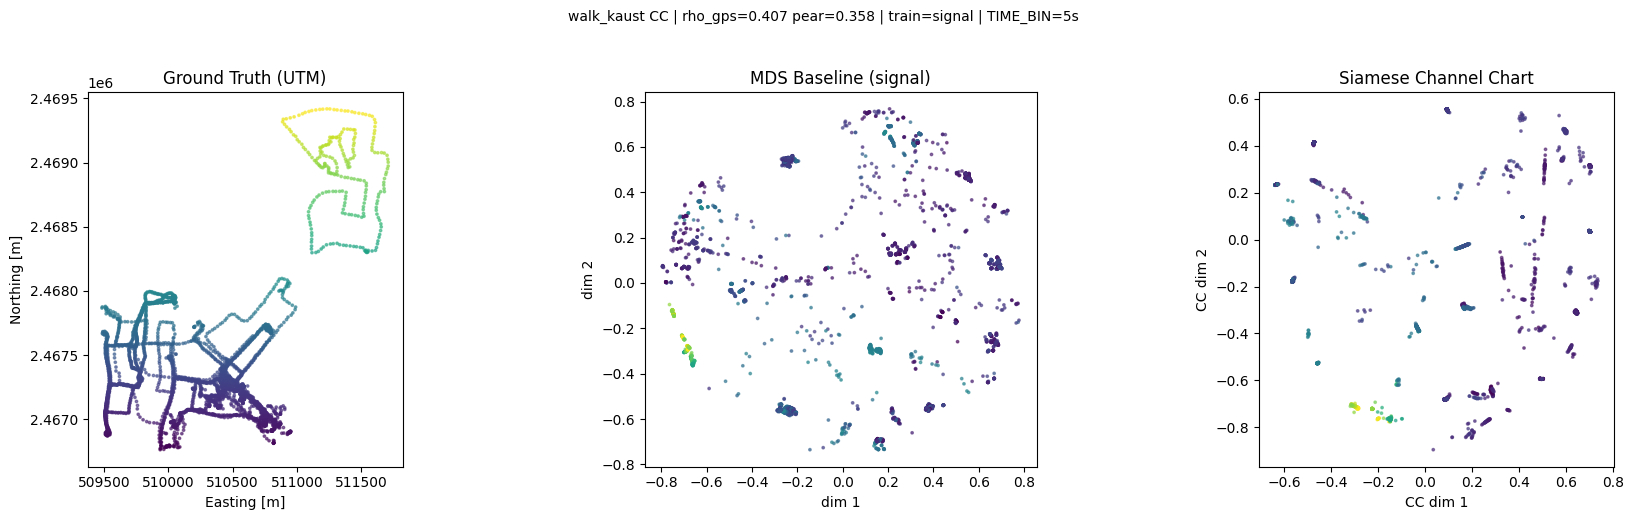

Final CC quality: Spearman(CC, GPS)=0.4065  Pearson=0.3577


In [ ]:
if CAN_PLOT_CC:
    d_cc_eval = cdist(cc_positions, cc_positions, metric='euclidean')
    d_cc_flat_rho = d_cc_eval[tri]
    fin_rho = np.isfinite(d_cc_flat_rho) & np.isfinite(D_true_flat)
    if fin_rho.sum() > 100:
        rho_gps, _ = spearmanr(d_cc_flat_rho[fin_rho], D_true_flat[fin_rho])
        pear_gps = float(np.corrcoef(d_cc_flat_rho[fin_rho], D_true_flat[fin_rho])[0, 1])
    else:
        rho_gps, pear_gps = np.nan, np.nan

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    plot_colorized(pos_sub, pos_sub, title="Ground Truth (UTM)", ax=axes[0], show=False)
    axes[0].set_xlabel("Easting [m]")
    axes[0].set_ylabel("Northing [m]")
    plot_colorized(proj_mds, pos_sub, title="MDS Baseline (signal)", ax=axes[1], show=False)
    axes[1].set_xlabel("dim 1")
    axes[1].set_ylabel("dim 2")
    plot_colorized(cc_positions, pos_sub, title="Siamese Channel Chart", ax=axes[2], show=False)
    axes[2].set_xlabel("CC dim 1")
    axes[2].set_ylabel("CC dim 2")

    plt.suptitle(
        f"walk_kaust CC | rho_gps={rho_gps:.3f} pear={pear_gps:.3f} | train=signal | TIME_BIN={TIME_BIN}",
        fontsize=10,
        y=1.03
    )
    plt.tight_layout()
    plt.savefig('cc_walk_kaust_chart.png', dpi=200, bbox_inches='tight')
    plt.show()

    print(f"Final CC quality: Spearman(CC, GPS)={rho_gps:.4f}  Pearson={pear_gps:.4f}")
else:
    print('Skipping final chart: collapsed or non-finite embedding')


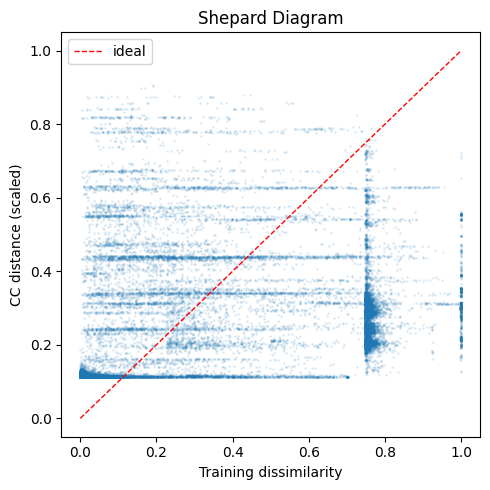

In [ ]:
if CAN_PLOT_CC:
    fin_shep_plot = np.isfinite(d_train_flat) & np.isfinite(d_cc_scaled)
    if fin_shep_plot.sum() < 100:
        print('Skipping Shepard diagram: too few finite pairs')
    else:
        fig, ax = plt.subplots(figsize=(5, 5))
        idx_plot = np.where(fin_shep_plot)[0]
        subsample_shep = np.random.choice(idx_plot, size=min(50000, len(idx_plot)), replace=False)
        ax.scatter(d_train_flat[subsample_shep], d_cc_scaled[subsample_shep], s=1, alpha=0.1, rasterized=True)
        vmax = np.nanmax(d_train_flat[fin_shep_plot])
        ax.plot([0, vmax], [0, vmax], 'r--', lw=1, label='ideal')
        ax.set_xlabel("Training dissimilarity")
        ax.set_ylabel("CC distance (scaled)")
        ax.set_title("Shepard Diagram")
        ax.legend()
        plt.tight_layout()
        plt.savefig('cc_walk_kaust_shepard.png', dpi=200, bbox_inches='tight')
        plt.show()
else:
    print('Skipping Shepard diagram: embedding invalid/collapsed')

In [ ]:
print()
print("=" * 80)
print("  Channel Charting Quality Summary — walk_kaust")
print("=" * 80)
n_files = len(files) if 'files' in dir() else '?'
print(f"  DATASET              = walk_kaust (KAUST walking, {n_files} files)")
print(f"  SAMPLES (total)      = {N_total:,}")
print(f"  SAMPLES (subsampled) = {N}")
print(f"  FEATURE_DIM          = {INPUT_DIM}")
print("  SELECTED_FEATURE_SET = RSRP + RSRQ")
print(f"  TIME_BIN             = {TIME_BIN}")
print(f"  MIN_APPEARANCES      = {MIN_APPEARANCES}")
print(f"  TRAIN_DISTANCE_SOURCE= {best_name}")
print(f"  USE_FUSION           = {USE_FUSION}")
print(f"  USE_GEODESIC         = {USE_GEODESIC}")
print(f"  CHOSEN_MIN_OVERLAP   = {MIN_OVERLAP}")
print(f"  CHOSEN_OVERLAP_LAMBDA= {OVERLAP_LAMBDA}")
print(f"  observed_ratio       = {mask_sub.mean():.6f}")
print(f"  D_signal finite frac = {finite_offdiag_frac:.6f}")
print(f"  Spearman(signal,GPS) = {rho_signal_gps:.4f}" if np.isfinite(rho_signal_gps) else f"  Spearman(signal,GPS) = {rho_signal_gps}")
print(f"  Pearson(signal,GPS)  = {pear_signal_gps:.4f}" if np.isfinite(pear_signal_gps) else f"  Pearson(signal,GPS)  = {pear_signal_gps}")
print(f"  Spearman(MDS,GPS)    = {rho_mds_gps:.4f}" if np.isfinite(rho_mds_gps) else f"  Spearman(MDS,GPS)    = {rho_mds_gps}")
print(f"  Pearson(MDS,GPS)     = {pear_mds_gps:.4f}" if np.isfinite(pear_mds_gps) else f"  Pearson(MDS,GPS)     = {pear_mds_gps}")
print(f"  Spearman(CC,GPS)     = {rho_cc_gps:.4f}" if np.isfinite(rho_cc_gps) else f"  Spearman(CC,GPS)     = {rho_cc_gps}")
print(f"  Pearson(CC,GPS)      = {pear_cc_gps:.4f}" if np.isfinite(pear_cc_gps) else f"  Pearson(CC,GPS)      = {pear_cc_gps}")
print(f"  Kruskal Stress raw   = {kruskal_stress_raw}")
print(f"  Kruskal Stress affine= {kruskal_stress_affine}")
print(f"  Spearman rho (CC)    = {rho_cc:.4f}" if np.isfinite(rho_cc) else f"  Spearman rho (CC)    = {rho_cc}")
D_eval = D_train.copy()
D_eval = 0.5 * (D_eval + D_eval.T)
np.fill_diagonal(D_eval, 0.0)
fin_eval_D = np.isfinite(D_eval)
if not fin_eval_D.all():
    fill_eval = np.nanmax(D_eval[fin_eval_D]) if fin_eval_D.any() else 1.0
    D_eval[~fin_eval_D] = fill_eval
valid_cc = np.isfinite(cc_positions).all(axis=1) if CAN_PLOT_CC else np.zeros(N, dtype=bool)
valid_d = np.isfinite(D_eval).all(axis=1)
keep = valid_cc & valid_d
if keep.sum() < 30:
    print('  TW/CO skipped: not enough finite points.')
else:
    D_eval_sub = D_eval[np.ix_(keep, keep)]
    cc_sub = cc_positions[keep]
    k_tutorial = int(np.sqrt(len(cc_sub)))
    for k in [5, 10, 20, k_tutorial]:
        k_use = min(k, len(cc_sub) - 2)
        if k_use < 2:
            continue
        tw = sklearn_tw(D_eval_sub, cc_sub, n_neighbors=k_use, metric='precomputed')
        co = continuity(D_eval_sub, cc_sub, n_neighbors=k_use)
        print(f"  TW(k={k_use:4d}) = {tw:.4f}    CO(k={k_use:4d}) = {co:.4f}")
print("=" * 80)
print("Matrix redesign: cell-specific fingerprint columns")
print("Missing values kept as NaN + mask")
print("Time fusion: OFF")
print("Geodesic: OFF")
print("Training target: signal-only")



  Channel Charting Quality Summary — walk_kaust
  DATASET              = walk_kaust (KAUST walking, 69 files)
  SAMPLES (total)      = 14,239
  SAMPLES (subsampled) = 3999
  FEATURE_DIM          = 156
  SELECTED_FEATURE_SET = RSRP + RSRQ
  TIME_BIN             = 5s
  MIN_APPEARANCES      = 10
  TRAIN_DISTANCE_SOURCE= fused_alpha=0.3
  USE_FUSION           = False
  USE_GEODESIC         = False
  CHOSEN_MIN_OVERLAP   = 2
  CHOSEN_OVERLAP_LAMBDA= 0.3
  observed_ratio       = 0.027696
  D_signal finite frac = 0.097501
  Spearman(signal,GPS) = 0.1759
  Pearson(signal,GPS)  = 0.2103
  Spearman(MDS,GPS)    = 0.4722
  Pearson(MDS,GPS)     = 0.4053
  Spearman(CC,GPS)     = 0.4065
  Pearson(CC,GPS)      = 0.3577
  Kruskal Stress raw   = 0.8062545432009867
  Kruskal Stress affine= 0.724156623121272
  Spearman rho (CC)    = 0.6449
  TW(k=   5) = 0.9534    CO(k=   5) = 0.9535
  TW(k=  10) = 0.9524    CO(k=  10) = 0.9510
  TW(k=  20) = 0.9494    CO(k=  20) = 0.9486
  TW(k=  63) = 0.9346    CO(k=  